In [1]:
# bibliotecques
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Chemin d'accès 
ROOT = Path.cwd().parent 
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))
print(f"Project root: {ROOT}")

from src.data_loader import *
from src.periodicity import *
from src.hull_white import *
from src.sinusoidal_hw import *
from src.monte_carlo import *
from src.calibration import *
print("Imports OK")


Project root: C:\Users\Manuel\Desktop\sinusoidal_hw
Imports OK


# Analyse de la Périodicité et Calibrage de Omega

Objectifs :
1. Identifier les cycles dominants via FFT (3.7, 5.5, 11, 22 ans).
2. Valider la non-stationnarité (ADF Test).
4. Calibrer le paramètre de fréquence $\omega$ pour le modèle Sinusoidal.

In [4]:
# Configuration globale des graphiques
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

In [6]:
#1. Chargement des Données
data_path = ROOT / 'data' / 'fredgraph.csv'
try:
    loader = YieldDataLoader(str(data_path))
    df = loader.load_data()
    print(f"Données chargées avec succès: {df.shape}")
except Exception as e:
    print(f"Erreur critique lors du chargement: {e}")

# Initialisation de l'analyseur
analyzer = PeriodicityAnalyzer(df)

Données chargées. 1292 lignes supprimées (NaN/Jours fériés).
Période: 1993-10-01 à 2022-12-30
Données chargées avec succès: (7317, 8)


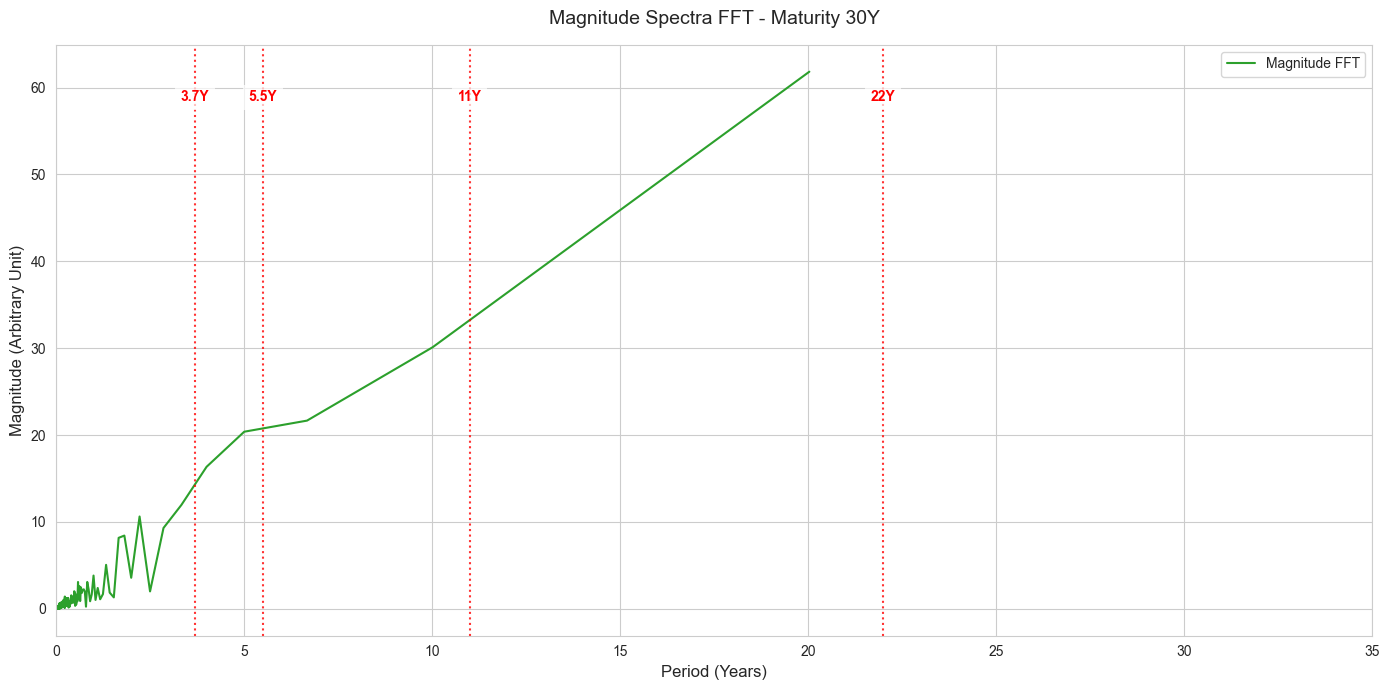

In [10]:
#2. Analyse Spectrale (FFT)
# Le papier identifie des cycles de **3.7, 5.5, 11 et 22 ans**.
# Nous nous concentrons sur la maturité **30 ans** (ou la plus longue disponible) pour capter les cycles longs.

target_tenor = '30Y'

try:
    periods, magnitude = analyzer.compute_fft(target_tenor)

    # Tracé du spectre
    plt.figure(figsize=(14, 7))
    plt.plot(periods, magnitude, color='#2ca02c', linewidth=1.5, label='Magnitude FFT')
    
    # Paramètres graphiques
    plt.title(f'Magnitude Spectra FFT - Maturity {target_tenor}', fontsize=14, pad=15)
    plt.xlabel('Period (Years)', fontsize=12)
    plt.ylabel('Magnitude (Arbitrary Unit)', fontsize=12)
    plt.xlim(0, 35)  # Focus sur la zone d'intérêt 0-35 ans
    
    # Annotation des cycles théoriques du papier
    expected_cycles = [3.7, 5.5, 11, 22]
    for cycle in expected_cycles:
        plt.axvline(x=cycle, color='red', linestyle=':', alpha=0.8, linewidth=1.5)
        plt.text(cycle, plt.ylim()[1]*0.9, f'{cycle}Y', color='red', ha='center', fontweight='bold', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

    plt.legend()
    plt.tight_layout()
    # plt.savefig("FFT.png", dpi=300, bbox_inches='tight')
    plt.show()

except ValueError as e:
    print(e)

In [12]:
#3. Tests Statistiques
# Le papier indique que les séries sont non-stationnaires (ADF p-value > 0.05) et fortement autocorrélées (Ljung-Box p-value ~ 0.000).

print(f"--- Tests Statistiques pour {target_tenor} ---")
stats = analyzer.run_statistical_tests(target_tenor)
for test_name, p_val in stats.items():
    status = "Non-Stationnaire (H0 non rejetée)" if "ADF" in test_name and p_val > 0.05 else "Significatif"
    print(f"{test_name:<20} : {p_val:.5f} -> {status}")

--- Tests Statistiques pour 30Y ---
ADF p-value          : 0.53570 -> Non-Stationnaire (H0 non rejetée)
Ljung-Box p-value    : 0.00000 -> Significatif


In [14]:
# 4. Calibrage du paramètre Omega ($\omega$)
# Le modèle sinusoïdal est défini par $\kappa_t = \kappa_0 + A \sin(\omega t)$.
# Le papier fixe $\omega$ sur le cycle de 22 ans.

print("\n--- Calibration de Omega ---")

# Recherche du pic dominant dans la zone "Long Terme" (15-30 ans)
dominant_period = analyzer.find_dominant_period(target_tenor, min_period=15, max_period=30)

if dominant_period:
    # Formule: w = 2 * pi / (T_annees * 365)
    omega_calculated = 2 * np.pi / (dominant_period * 365)
    omega_paper_target = 0.00078  # Valeur approximative du papier
    
    print(f"Cycle dominant détecté (Data) : {dominant_period:.2f} ans")
    print(f"Omega calculé (Data) : {omega_calculated:.6f} rad/jour")
    print(f"Omega cible (Papier) : {omega_paper_target:.6f} rad/jour")
    
    error = abs(omega_calculated - omega_paper_target)
    print(f"Écart absolu : {error:.6f}")

    FINAL_OMEGA = omega_calculated
    
else:
    print("ATTENTION : Pas de cycle clair détecté dans la zone 15-30 ans.")
    # Fallback sur la valeur du papier si échec
    FINAL_OMEGA = 0.00078 

print(f"\nValeur retenue pour la modélisation : omega = {FINAL_OMEGA:.6f}")


--- Calibration de Omega ---
Cycle dominant détecté (Data) : 20.03 ans
Omega calculé (Data) : 0.000859 rad/jour
Omega cible (Papier) : 0.000780 rad/jour
Écart absolu : 0.000079

Valeur retenue pour la modélisation : omega = 0.000859
